In [2]:
import numpy as np
import pandas as pd
from scapy.all import rdpcap, raw
import matplotlib.pyplot as plt
import seaborn as sns



𝗔𝘁𝘂𝗿 𝗝𝗮𝗹𝘂𝗿 𝗣𝗮𝗸𝗲𝘁 𝗱𝗮𝗻 𝗽𝗮𝗻𝗴𝗴𝗶𝗹 𝗱𝗮𝘁𝗮𝘀𝗲𝘁

In [3]:
# Memamnggil data
# TRAIN_PCAP_PATH = training.pcap
# TRAIN_LBELS_PATH = label(y) train

# TEST_PCAP_PATH = test.pcap
# TEST_LABELS_PATH = label(y) test

# --- KONFIGURASI DAN PATH FILE ---
BASE_PATH = '/home/dani/Documents/tugas akhir/TugasAkhir/DataTugasAkhirku2026/dataTOWIDSmentah/'
TRAIN_PCAP_PATH = BASE_PATH + 'Automotive_Ethernet_with_Attack_original_10_17_19_50_training.pcap'
TRAIN_LABELS_PATH = BASE_PATH + 'y_train.csv'

# Kita definisikan juga path untuk data testing untuk nanti
TEST_PCAP_PATH = BASE_PATH + 'Automotive_Ethernet_with_Attack_original_10_17_20_04_test.pcap'
TEST_LABELS_PATH = BASE_PATH + 'y_test.csv'

print("Langkah 1 Selesai: Library dan path sudah siap.")

Langkah 1 Selesai: Library dan path sudah siap.


𝗕𝘂𝗮𝘁 𝗙𝘂𝗻𝗴𝘀𝗶 𝗘𝗸𝘀𝘁𝗿𝗮𝗸 𝗣𝗮𝗸𝗲𝘁 𝗱𝗮𝗻 𝗕𝘂𝗶𝗹 𝗪𝗶𝗻𝗱𝗼𝘄

In [4]:
# fungsi untuk ekstrak paket dari file pcap dengan panjang tetap 64 byte
Nbyte=256
def extract_packets(pcap_path, n_bytes=Nbyte):
    packets = rdpcap(pcap_path)
    data = []

    for pkt in packets:
        pkt_bytes = raw(pkt)

        if len(pkt_bytes) < n_bytes:
            pkt_bytes = pkt_bytes + bytes(n_bytes - len(pkt_bytes))  # zero padding
        else:
            pkt_bytes = pkt_bytes[:n_bytes]  # truncate

        data.append(np.frombuffer(pkt_bytes, dtype=np.uint8))

    return np.array(data)  # (num_packets, 64)


𝗣𝗿𝗼𝘀𝗲𝘀 𝗧𝗿𝗮𝗶𝗻 𝗕𝗶𝗻𝗮𝗿𝘆 𝗖𝗹𝗮𝘀𝘀 𝗱𝗮𝗿𝗶 𝗘𝗸𝘀𝘁𝗿𝗮𝗸 𝗛𝗶𝗻𝗴𝗴𝗮 𝗕𝘂𝗶𝗹𝗱 𝗪𝗶𝗻𝗱𝗼𝘄

In [5]:
# Pengecekkan Data dulu
# data train di masukkan ke variabel df_labels_train
# lalu kolom 2 yang berisi binary class di masukkn ke variabel labels_train1

# --- MEMUAT LABEL TRAINING ---
print("Memuat file label dari:", TRAIN_LABELS_PATH)
df_labels_train = pd.read_csv(TRAIN_LABELS_PATH , header=None)

# Mengambil semua nilai dari kolom pertama dan menyimpannya sebagai array numpy
labels_train1 = df_labels_train.iloc[:, 1].values

# --- MEMERIKSA LABEL ---
print(f"\nBerhasil memuat {len(labels_train1)} label.")
print("Contoh 5 label pertama:", labels_train1[:5])
print("Distribusi Label:")
print(df_labels_train.iloc[:, 1].value_counts())

Memuat file label dari: /home/dani/Documents/tugas akhir/TugasAkhir/DataTugasAkhirku2026/dataTOWIDSmentah/y_train.csv

Berhasil memuat 1203737 label.
Contoh 5 label pertama: ['Normal' 'Normal' 'Normal' 'Normal' 'Normal']
Distribusi Label:
1
Normal      954912
Abnormal    248825
Name: count, dtype: int64


/tmp/ipykernel_81803/1223957234.py:7: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_labels_train = pd.read_csv(TRAIN_LABELS_PATH , header=None)


In [6]:
# kalau sebelumnya kolom 1, sekarang kolom 2 yang berisi multi class di masukkn ke variabel labels_train2

# Mengambil semua nilai dari kolom pertama dan menyimpannya sebagai array numpy
labels_train2 = df_labels_train.iloc[:, 2].values

# --- MEMERIKSA LABEL ---
print(f"\nBerhasil memuat {len(labels_train2)} label.")
print("Contoh 5 label pertama:", labels_train2[:5])
print("Distribusi Label:")
print(df_labels_train.iloc[:, 2].value_counts())


Berhasil memuat 1203737 label.
Contoh 5 label pertama: ['Normal' 'Normal' 'Normal' 'Normal' 'Normal']
Distribusi Label:
2
Normal    954912
C_D        85466
P_I        64635
F_I        35112
M_F        33765
C_R        29847
Name: count, dtype: int64


In [7]:
# proses train pcap ke fungsi ekstrak paket
x_pkt_train=extract_packets(TRAIN_PCAP_PATH)

In [8]:
# Ambil label multiclass
multi_labels_text = df_labels_train.iloc[:, 2]

# Mapping label
label_map = {
    'Normal': 0,
    'C_D': 1,
    'P_I': 2,
    'F_I': 3,
    'M_F': 4,
    'C_R': 5
}

# Konversi ke integer
y_label_train = multi_labels_text.map(label_map).values

In [9]:
print(np.unique(y_label_train))

[0 1 2 3 4 5]


In [10]:
import pandas as pd

pd.Series(y_label_train).value_counts().sort_index()

0    954912
1     85466
2     64635
3     35112
4     33765
5     29847
Name: count, dtype: int64

In [11]:
for cls in [0,1,2,3,4,5]:
    idx = np.where(y_label_train == cls)[0]
    print(cls, idx[0], idx[-1])

0 0 1203736
1 140310 318976
2 994520 1196496
3 775560 921297
4 566331 681510
5 376323 477908


In [12]:
# from sklearn.model_selection import train_test_split

# # split 70:30
# X_train, X_eval, y_train, y_eval = train_test_split(
#     x_pkt_train,
#     y_label_train,
#     test_size=0.30,
#     shuffle=False
# )

In [13]:
# cek informasi hasil ekstrak paket dan contoh data pertama
print(type(x_pkt_train))
print(x_pkt_train.shape)
print(x_pkt_train.dtype)
x_pkt_train[0]

<class 'numpy.ndarray'>
(1203737, 256)
uint8


array([145, 239,   0,   0, 254,   0,   0, 252, 112,   0,   0,   3, 129,
         0,   0,   2,  34, 240,   0, 136,  22,   0,   1,  35,  69, 103,
       137, 171, 205, 239,   0,   0,   0,   0,   0,   0,   0,   0,   1,
       136,  95, 160,  63,   6, 196,  96, 160,   0,   0,   0,  45, 145,
       232, 183,  71,  64,  65,  16,   0,   0,   1, 224,  15, 174, 129,
       128,   5,  33,  97, 137, 159,  65,   0,   0,   0,   1,   6,   1,
         4,   0,  24,   8,  16, 128,   0,   0,   0,   1,  97, 225, 130,
       111,  51, 239, 135, 226,  86, 238, 222, 188, 102,  12,  24,  83,
         9, 106, 141, 246,  35,  27, 162, 252,  88, 240,   8, 114, 129,
       110, 154,  95,  47, 121, 164, 254, 165,  25,  78, 195, 183,  85,
       185,  84, 157, 215,  51,  12, 213, 107, 113,  24,  54, 217, 114,
        57,  35,  58,  22, 232, 235, 134, 210, 121, 206,  53,  98, 222,
       244, 246,  16, 173,  94,  59, 239, 108, 110, 248,  57, 245,  48,
       239, 246, 222,  14, 235, 151,  44,  81,   8, 127,  60, 12

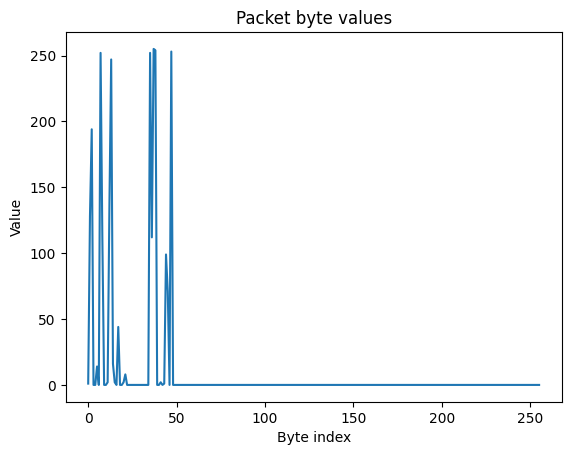

In [14]:
# Visualisasi salah satu paket byte values terutama yang sudah di zero padding
import matplotlib.pyplot as plt

plt.plot(x_pkt_train[7])
plt.title("Packet byte values")
plt.xlabel("Byte index")
plt.ylabel("Value")
plt.show()


In [15]:
def build_windows(X_pkt, y_pkt, N=Nbyte, step=Nbyte):
    X_win = []
    y_win = []

    # Menyimpan window yang memiliki lebih dari satu jenis serangan
    multi_attack_windows = []

    for i in range(0, len(X_pkt) - N + 1, step):

        window_data = X_pkt[i:i+N]
        window_label = y_pkt[i:i+N]

        # Ambil semua label serangan (selain Normal=0)
        attack_labels = np.unique(window_label[window_label != 0])

        if len(attack_labels) == 0:
            label = 0

        elif len(attack_labels) == 1:
            label = int(attack_labels[0])

        else:
            label = -1   # sementara
            multi_attack_windows.append({
                "window": len(X_win),
                "start_index": i,
                "attack_labels": attack_labels.tolist()
            })

        X_win.append(window_data)
        y_win.append(label)

    return np.array(X_win), np.array(y_win), multi_attack_windows

In [16]:
x_seq_train, y_seq_train, multi_attack = build_windows(
    x_pkt_train,
    y_label_train
)

In [17]:
print("Jumlah window dengan >1 jenis serangan :", len(multi_attack))

Jumlah window dengan >1 jenis serangan : 0


In [18]:
# Periksa hasilnya, dimana didapat sekitar 1.2 juta window denan panjang 64 paket per window dan panjang paket 64 byte
x_seq_train.shape, y_seq_train.shape, np.unique(y_seq_train)

((4702, 256, 256), (4702,), array([0, 1, 2, 3, 4, 5]))

In [19]:
import pandas as pd

# Distribusi label window
window_dist = (
    pd.Series(y_seq_train)
    .value_counts()
    .sort_index()
    .rename(index={
        0: "Normal",
        1: "C_D",
        2: "P_I",
        3: "F_I",
        4: "M_F",
        5: "C_R"
    })
)

print(window_dist)

Normal    1908
C_D        699
P_I        758
F_I        530
M_F        410
C_R        397
Name: count, dtype: int64


In [20]:
window_df = pd.DataFrame({
    "Jumlah Window": pd.Series(y_seq_train).value_counts().sort_index()
})

window_df.index = ["Normal", "C_D", "P_I", "F_I", "M_F", "C_R"]

window_df["Persentase (%)"] = (
    window_df["Jumlah Window"] /
    window_df["Jumlah Window"].sum() * 100
).round(2)

print(window_df)

        Jumlah Window  Persentase (%)
Normal           1908           40.58
C_D               699           14.87
P_I               758           16.12
F_I               530           11.27
M_F               410            8.72
C_R               397            8.44


In [21]:
import numpy as np

train_idx = []
eval_idx = []

classes = np.unique(y_seq_train)

for cls in classes:

    idx = np.where(y_seq_train == cls)[0]

    split = int(len(idx) * 0.7)

    train_idx.extend(idx[:split])
    eval_idx.extend(idx[split:])

In [22]:
X_train = x_seq_train[train_idx]
y_train = y_seq_train[train_idx]

X_eval = x_seq_train[eval_idx]
y_eval = y_seq_train[eval_idx]

In [23]:
import pandas as pd

print("TRAIN")
print(pd.Series(y_train).value_counts().sort_index())

print("\nEVAL")
print(pd.Series(y_eval).value_counts().sort_index())

TRAIN
0    1335
1     489
2     530
3     371
4     287
5     277
Name: count, dtype: int64

EVAL
0    573
1    210
2    228
3    159
4    123
5    120
Name: count, dtype: int64


In [24]:
for cls, name in zip(
    [0,1,2,3,4,5],
    ["Normal","C_D","P_I","F_I","M_F","C_R"]
):
    idx = np.where(y_seq_train == cls)[0]
    print(f"{name:7s} : {idx[0]} - {idx[-1]} ({len(idx)} window)")

Normal  : 0 - 4701 (1908 window)
C_D     : 548 - 1246 (699 window)
P_I     : 3884 - 4673 (758 window)
F_I     : 3029 - 3598 (530 window)
M_F     : 2212 - 2662 (410 window)
C_R     : 1470 - 1866 (397 window)


In [25]:
import hashlib

hashes = []

for w in x_seq_train:
    hashes.append(hashlib.md5(w.tobytes()).hexdigest())

print("Window unik :", len(set(hashes)))
print("Total window:", len(hashes))

Window unik : 4702
Total window: 4702


In [26]:
from sklearn.model_selection import train_test_split
import numpy as np

train_idx = []
eval_idx = []

for cls in np.unique(y_seq_train):

    idx = np.where(y_seq_train == cls)[0]

    idx_train, idx_eval = train_test_split(
        idx,
        test_size=0.30,
        random_state=42,
        shuffle=True
    )

    train_idx.extend(idx_train)
    eval_idx.extend(idx_eval)

# Supaya urutan train/eval tidak berkelompok
train_idx = np.array(train_idx)
eval_idx = np.array(eval_idx)

np.random.seed(42)
np.random.shuffle(train_idx)
np.random.shuffle(eval_idx)

X_train = x_seq_train[train_idx]
y_train = y_seq_train[train_idx]

X_eval = x_seq_train[eval_idx]
y_eval = y_seq_train[eval_idx]

In [27]:
import pandas as pd

print("TRAIN")
print(pd.Series(y_train).value_counts().sort_index())

print("\nEVAL")
print(pd.Series(y_eval).value_counts().sort_index())

TRAIN
0    1335
1     489
2     530
3     371
4     287
5     277
Name: count, dtype: int64

EVAL
0    573
1    210
2    228
3    159
4    123
5    120
Name: count, dtype: int64


In [28]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

for c, w in zip(classes, weights):
    print(f"Class {c}: {w:.3f}")

Class 0: 0.411
Class 1: 1.121
Class 2: 1.034
Class 3: 1.478
Class 4: 1.910
Class 5: 1.979


In [29]:
import os
import numpy as np

SAVE_DIR = "/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize256lv3multiclass/"
train_path = os.path.join(SAVE_DIR, "tow_ids_train_windows.npz")


np.savez(train_path, X=X_train, y=y_train)

print("File train berhasil disimpan di:")
print(train_path)

del train_path, X_train, y_train

SAVE_DIR = "/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize256lv3multiclass/"
eval_path = os.path.join(SAVE_DIR, "tow_ids_eval_windows.npz")

np.savez(eval_path, X=X_eval, y=y_eval)

print("File eval berhasil disimpan di:")
print(eval_path)

del eval_path, X_eval, y_eval

File train berhasil disimpan di:
/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize256lv3multiclass/tow_ids_train_windows.npz
File eval berhasil disimpan di:
/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize256lv3multiclass/tow_ids_eval_windows.npz


In [30]:
# Periksa Data dulu
# data test di masukkan ke variabel df_labels_test
# --- MEMUAT LABEL Testing ---
print("Memuat file label dari:", TEST_LABELS_PATH)
df_labels_test = pd.read_csv(TEST_LABELS_PATH , header=None)

# Mengambil semua nilai dari kolom pertama dan menyimpannya sebagai array numpy
labels_test1 = df_labels_test.iloc[:, 1].values

# --- MEMERIKSA LABEL ---
print(f"\nBerhasil memuat {len(labels_test1)} label.")
print("Contoh 5 label pertama:", labels_test1[:5])
print("Distribusi Label:")
print(df_labels_test.iloc[:, 1].value_counts())
print(df_labels_test.head())


Memuat file label dari: /home/dani/Documents/tugas akhir/TugasAkhir/DataTugasAkhirku2026/dataTOWIDSmentah/y_test.csv

Berhasil memuat 791611 label.
Contoh 5 label pertama: ['Normal' 'Normal' 'Normal' 'Normal' 'Normal']
Distribusi Label:
1
Normal      660777
Abnormal    130834
Name: count, dtype: int64
   0       1       2
0  1  Normal  Normal
1  2  Normal  Normal
2  3  Normal  Normal
3  4  Normal  Normal
4  5  Normal  Normal


In [31]:
# sekarang cek kolom 2 yang berisi multi class di masukkn ke variabel labels_test2
# Mengambil semua nilai dari kolom pertama dan menyimpannya sebagai array numpy
labels_test2 = df_labels_test.iloc[:, 2].values

# --- MEMERIKSA LABEL ---
print(f"\nBerhasil memuat {len(labels_test2)} label.")
print("Contoh 5 label pertama:", labels_test2[:5])
print("Distribusi Label:")
print(df_labels_test.iloc[:, 2].value_counts())


Berhasil memuat 791611 label.
Contoh 5 label pertama: ['Normal' 'Normal' 'Normal' 'Normal' 'Normal']
Distribusi Label:
2
Normal    660777
C_D        41203
C_R        29847
P_I        26013
F_I        16962
M_F        16809
Name: count, dtype: int64


In [32]:
# proses test pcap ke fungsi ekstrak paket
x_pkt_test=extract_packets(TEST_PCAP_PATH)

In [33]:
# Ambil label multiclass
multi_labels_text = df_labels_test.iloc[:, 2]

# Mapping label
label_map = {
    'Normal': 0,
    'C_D': 1,
    'P_I': 2,
    'F_I': 3,
    'M_F': 4,
    'C_R': 5
}

# Konversi ke integer
y_label_test = multi_labels_text.map(label_map).values

In [34]:
import pandas as pd

pd.Series(y_label_test).value_counts().sort_index()

0    660777
1     41203
2     26013
3     16962
4     16809
5     29847
Name: count, dtype: int64

In [35]:
for cls in [0,1,2,3,4,5]:
    idx = np.where(y_label_test == cls)[0]
    print(cls, idx[0], idx[-1])

0 0 791610
1 155832 242509
2 709806 786136
3 591117 655106
4 482386 533088
5 297261 400315


In [36]:
x_seq_test, y_seq_test, multi_attack_test = build_windows(
    x_pkt_test,
    y_label_test
)

In [40]:
print("Jumlah window dengan >1 jenis serangan :", len(multi_attack_test))

Jumlah window dengan >1 jenis serangan : 0


In [41]:
# Periksa hasilnya, dimana didapat sekitar 1.2 juta window denan panjang 64 paket per window dan panjang paket 64 byte
x_seq_test.shape, y_seq_test.shape, np.unique(y_seq_test)

((3092, 256, 256), (3092,), array([0, 1, 2, 3, 4, 5]))

In [42]:
import pandas as pd

# Distribusi label window
window_dist = (
    pd.Series(y_seq_test)
    .value_counts()
    .sort_index()
    .rename(index={
        0: "Normal",
        1: "C_D",
        2: "P_I",
        3: "F_I",
        4: "M_F",
        5: "C_R"
    })
)

print(window_dist)

Normal    1600
C_D        340
P_I        299
F_I        251
M_F        199
C_R        403
Name: count, dtype: int64


In [45]:
window_df = pd.DataFrame({
    "Jumlah Window": pd.Series(y_seq_test).value_counts().sort_index()
})

window_df.index = ["Normal", "C_D", "P_I", "F_I", "M_F", "C_R"]

window_df["Persentase (%)"] = (
    window_df["Jumlah Window"] /
    window_df["Jumlah Window"].sum() * 100
).round(2)

print(window_df)

        Jumlah Window  Persentase (%)
Normal           1600           51.75
C_D               340           11.00
P_I               299            9.67
F_I               251            8.12
M_F               199            6.44
C_R               403           13.03


In [46]:
for cls, name in zip(
    [0,1,2,3,4,5],
    ["Normal","C_D","P_I","F_I","M_F","C_R"]
):
    idx = np.where(y_seq_test == cls)[0]
    print(f"{name:7s} : {idx[0]} - {idx[-1]} ({len(idx)} window)")

Normal  : 0 - 3091 (1600 window)
C_D     : 608 - 947 (340 window)
P_I     : 2772 - 3070 (299 window)
F_I     : 2309 - 2559 (251 window)
M_F     : 1884 - 2082 (199 window)
C_R     : 1161 - 1563 (403 window)


In [47]:
import hashlib

hashes = []

for w in x_seq_test:
    hashes.append(hashlib.md5(w.tobytes()).hexdigest())

print("Window unik :", len(set(hashes)))
print("Total window:", len(hashes))

Window unik : 3092
Total window: 3092


In [48]:
import os
import numpy as np

SAVE_DIR = "/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize256lv3multiclass/"
test_path = os.path.join(SAVE_DIR, "tow_ids_test_windows.npz")


np.savez(test_path, X=x_seq_test, y=y_seq_test)

print("File test berhasil disimpan di:")
print(test_path)

del test_path, x_seq_test, y_seq_test

File test berhasil disimpan di:
/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize256lv3multiclass/tow_ids_test_windows.npz


In [53]:
def normalize_minmax(X):
    return X.astype(np.float32) / 255.0



In [51]:
import os
import numpy as np

Loader = "/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize256lv3multiclass/"
SAVE_DIR = "/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize256lv3multiclass/norm/"

# Buat folder output jika belum ada
os.makedirs(SAVE_DIR, exist_ok=True)

train_path = os.path.join(Loader, "tow_ids_train_windows.npz")
eval_path = os.path.join(Loader, "tow_ids_eval_windows.npz")

# Load data
train_data = np.load(train_path)
eval_data = np.load(eval_path)

x_seq_train = train_data["X"]
y_seq_train = train_data["y"]

x_seq_eval = eval_data["X"]
y_seq_eval = eval_data["y"]

In [52]:
print("=== TRAIN ===")
print("X_train shape :", x_seq_train.shape)
print("y_train shape :", y_seq_train.shape)
print("X_train dtype :", x_seq_train.dtype)
print("y_train dtype :", y_seq_train.dtype)


print("=== EVAL ===")
print("X_eval shape :", x_seq_eval.shape)
print("y_eval shape :", y_seq_eval.shape)
print("X_eval dtype :", x_seq_eval.dtype)
print("y_eval dtype :", y_seq_eval.dtype)


=== TRAIN ===
X_train shape : (3289, 256, 256)
y_train shape : (3289,)
X_train dtype : uint8
y_train dtype : int64
=== EVAL ===
X_eval shape : (1413, 256, 256)
y_eval shape : (1413,)
X_eval dtype : uint8
y_eval dtype : int64


In [54]:
print("Train min:", x_seq_train.min())
print("Train max:", x_seq_train.max())
print("Train mean:", x_seq_train.mean())

print("Eval min:", x_seq_eval.min())
print("Eval max:", x_seq_eval.max())
print("Eval mean:", x_seq_eval.mean())


Train min: 0
Train max: 255
Train mean: 41.17587970143287
Eval min: 0
Eval max: 255
Eval mean: 41.457596570316646


In [55]:
x_train_norm = normalize_minmax(x_seq_train)
train_out = os.path.join(SAVE_DIR, "tow_ids_train_windows_norm.npz")
np.savez(train_out, X=x_train_norm, y=y_seq_train)
print("Saved normalis:")
print(train_out)

x_eval_norm = normalize_minmax(x_seq_eval)
eval_out = os.path.join(SAVE_DIR, "tow_ids_eval_windows_norm.npz")
np.savez(eval_out, X=x_eval_norm, y=y_seq_eval)
print("Saved normalis:")
print(eval_out)

Saved normalis:
/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize256lv3multiclass/norm/tow_ids_train_windows_norm.npz
Saved normalis:
/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize256lv3multiclass/norm/tow_ids_eval_windows_norm.npz


In [56]:
print("Train min:", x_train_norm.min())
print("Train max:", x_train_norm.max())
print("Train mean:", x_train_norm.mean())

print("Eval min:", x_eval_norm.min())
print("Eval max:", x_eval_norm.max())
print("Eval mean:", x_eval_norm.mean())


Train min: 0.0
Train max: 1.0
Train mean: 0.16147412
Eval min: 0.0
Eval max: 1.0
Eval mean: 0.16257788


In [57]:
import pandas as pd

print("=== TRAIN ===")
print(pd.Series(y_seq_train).value_counts().sort_index())

print("\n=== EVAL ===")
print(pd.Series(y_seq_eval).value_counts().sort_index())

=== TRAIN ===
0    1335
1     489
2     530
3     371
4     287
5     277
Name: count, dtype: int64

=== EVAL ===
0    573
1    210
2    228
3    159
4    123
5    120
Name: count, dtype: int64


In [58]:
import os
import numpy as np
test_path  = os.path.join(Loader, "tow_ids_test_windows.npz")
# load
test_data  = np.load(test_path)

x_seq_test  = test_data["X"]
y_seq_test  = test_data["y"]


In [59]:

print("\n=== TEST ===")
print("X_test shape  :", x_seq_test.shape)
print("y_test shape  :", y_seq_test.shape)
print("X_test dtype  :", x_seq_test.dtype)
print("y_test dtype  :", y_seq_test.dtype)



=== TEST ===
X_test shape  : (3092, 256, 256)
y_test shape  : (3092,)
X_test dtype  : uint8
y_test dtype  : int64


In [60]:
print("Train min:", x_seq_test.min())
print("Train max:", x_seq_test.max())
print("Train mean:", x_seq_test.mean())


Train min: 0
Train max: 255
Train mean: 42.740721476802854


In [61]:
x_test_norm  = normalize_minmax(x_seq_test)
test_out  = os.path.join(SAVE_DIR, "tow_ids_test_windows_norm.npz")

np.savez(test_out,  X=x_test_norm,  y=y_seq_test)

print("Saved normalis:")
print(test_out)


Saved normalis:
/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize256lv3multiclass/norm/tow_ids_test_windows_norm.npz


In [62]:
print("Train min:", x_test_norm.min())
print("Train max:", x_test_norm.max())
print("Train mean:", x_test_norm.mean())


Train min: 0.0
Train max: 1.0
Train mean: 0.16760969


In [63]:
import pandas as pd

print("=== Test ===")
print(pd.Series(y_seq_test).value_counts().sort_index())

=== Test ===
0    1600
1     340
2     299
3     251
4     199
5     403
Name: count, dtype: int64


In [64]:
del x_test_norm, y_seq_test, test_out
del x_eval_norm, y_seq_eval, eval_out

In [98]:
import numpy as np
import os
import gc
import pywt


In [ ]:
# def dwt_3wavelet_single(img):
#     LL1, _ = pywt.dwt2(img, 'coif1')
#     LL2, _ = pywt.dwt2(img, 'db3')
#     LL3, _ = pywt.dwt2(img, 'rbio1.3')

#     # 🔴 POTONG KE 32×32
#     LL1 = LL1[:128, :128]
#     LL2 = LL2[:128, :128]
#     LL3 = LL3[:128, :128]

#     return np.stack([LL1, LL2, LL3], axis=-1)


def dwt_3wavelet_single(img, level=2):

    coif = img.copy()
    db3  = img.copy()
    rbio = img.copy()

    for _ in range(level):
        coif, _ = pywt.dwt2(coif, 'coif1')
        db3, _  = pywt.dwt2(db3, 'db3')
        rbio, _ = pywt.dwt2(rbio, 'rbio1.3')

    # safeguard ukuran
    target_size = 256 // (2 ** level)

    coif = coif[:target_size, :target_size]
    db3  = db3[:target_size, :target_size]
    rbio = rbio[:target_size, :target_size]

    return np.stack([coif, db3, rbio], axis=-1)

In [100]:
import os
import numpy as np

Loader = "/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize256lv3multiclass/norm/"
SAVE_DIR = "/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize256lv3multiclass/norm/dwt"
SAVE_DIR2 = "/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize256lv3multiclass/norm/dwt/sample/"

# Buat folder jika belum ada
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(SAVE_DIR2, exist_ok=True)

train_path = os.path.join(Loader, "tow_ids_train_windows_norm.npz")
eval_path = os.path.join(Loader, "tow_ids_eval_windows_norm.npz")

# Load data
train_data = np.load(train_path)
eval_data = np.load(eval_path)

X = train_data["X"]
y = train_data["y"]

X_eval = eval_data["X"]
y_eval = eval_data["y"]

In [101]:
print("X shape :", X.shape)
print("X dtype :", X.dtype)

print("y shape :", y.shape)
print("y dtype :", y.dtype)

print("X_eval shape :", X_eval.shape)
print("X_eval dtype :", X_eval.dtype)

print("y_eval shape :", y_eval.shape)
print("y_eval dtype :", y_eval.dtype)

X shape : (3289, 256, 256)
X dtype : float32
y shape : (3289,)
y dtype : int64
X_eval shape : (1413, 256, 256)
X_eval dtype : float32
y_eval shape : (1413,)
y_eval dtype : int64


In [102]:
level = 2
target_size = 256 // (2 ** level)

N = X.shape[0]

X_dwt = np.empty(
    (N, target_size, target_size, 3),
    dtype=np.float32
)

for i in range(N):
    X_dwt[i] = dwt_3wavelet_single(X[i], level=level)

print("DWT Done:")
print("Shape:", X_dwt.shape)

DWT Done:
Shape: (3289, 64, 64, 3)


In [103]:


N = X_eval.shape[0]

X_eval_dwt = np.empty(
    (N, target_size, target_size, 3),
    dtype=np.float32
)

for i in range(N):
    X_eval_dwt[i] = dwt_3wavelet_single(X_eval[i], level=level)

print("DWT Done:")
print("Shape:", X_eval_dwt.shape)

DWT Done:
Shape: (1413, 64, 64, 3)


In [104]:
print("\n=== Statistik DWT ===")
print("Min :", X_dwt.min())
print("Max :", X_dwt.max())
print("Mean:", X_dwt.mean())
print("Shape:", X_dwt.shape)
print("Mean per channel:", X_dwt.mean(axis=(0,1,2)))
print("Std per channel :", X_dwt.std(axis=(0,1,2)))


print("\n=== Statistik DWT eval ===")
print("Min :", X_eval_dwt.min())
print("Max :", X_eval_dwt.max())
print("Mean:", X_eval_dwt.mean())
print("Shape:", X_eval_dwt.shape)
print("Mean per channel:", X_eval_dwt.mean(axis=(0,1,2)))
print("Std per channel :", X_eval_dwt.std(axis=(0,1,2)))


=== Statistik DWT ===
Min : -0.72264206
Max : 4.4806385
Mean: 0.70943135
Shape: (3289, 64, 64, 3)
Mean per channel: [0.70878893 0.7177686  0.6994723 ]
Std per channel : [0.8648363  0.8603525  0.83868045]

=== Statistik DWT eval ===
Min : -0.71327895
Max : 4.0488954
Mean: 0.71364737
Shape: (1413, 64, 64, 3)
Mean per channel: [0.7121145  0.72344047 0.70614195]
Std per channel : [0.85097617 0.85044396 0.86583793]


In [105]:
import numpy as np
import matplotlib.pyplot as plt
import os

np.random.seed(42)

# Nama label agar nama file lebih informatif
label_names = {
    0: "Normal",
    1: "C_D",
    2: "P_I",
    3: "F_I",
    4: "M_F",
    5: "C_R"
}

for label in sorted(label_names.keys()):

    # Semua index untuk label tersebut
    idx_label = np.where(y == label)[0]

    # Ambil 2 sample acak
    sample_idx = np.random.choice(idx_label, size=2, replace=False)

    for i, idx in enumerate(sample_idx, start=1):

        img = X_dwt[idx]

        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.title(f"{label_names[label]} (Label {label})")
        plt.axis("off")

        img_path = os.path.join(
            SAVE_DIR2,
            f"{label_names[label]}_sample{i}_idxtrain{idx}.png"
        )

        plt.savefig(img_path, bbox_inches="tight", pad_inches=0)
        plt.close()

print("Saved 2 sample images for each class.")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6390584..3.2616405].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.434161..3.0274508].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.32837418..3.0274508].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.32213306..3.0274508].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.44161606..3.0235293].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5574505..3.0235293].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4254

Saved 2 sample images for each class.


In [106]:
import numpy as np
import matplotlib.pyplot as plt
import os

np.random.seed(42)

# Nama label agar nama file lebih informatif
label_names = {
    0: "Normal",
    1: "C_D",
    2: "P_I",
    3: "F_I",
    4: "M_F",
    5: "C_R"
}

for label in sorted(label_names.keys()):

    # Semua index untuk label tersebut
    idx_label = np.where(y_eval == label)[0]

    # Ambil 2 sample acak
    sample_idx = np.random.choice(idx_label, size=2, replace=False)

    for i, idx in enumerate(sample_idx, start=1):

        img = X_eval_dwt[idx]

        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.title(f"{label_names[label]} (Label {label})")
        plt.axis("off")

        img_path = os.path.join(
            SAVE_DIR2,
            f"{label_names[label]}_sample{i}_idxeval{idx}.png"
        )

        plt.savefig(img_path, bbox_inches="tight", pad_inches=0)
        plt.close()

print("Saved 2 sample images for each class.")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.46568838..3.270588].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6917861..3.0274508].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.33507428..3.0274508].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.31141073..3.0274508].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.52156013..3.0938463].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49103087..3.0764704].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.37

Saved 2 sample images for each class.


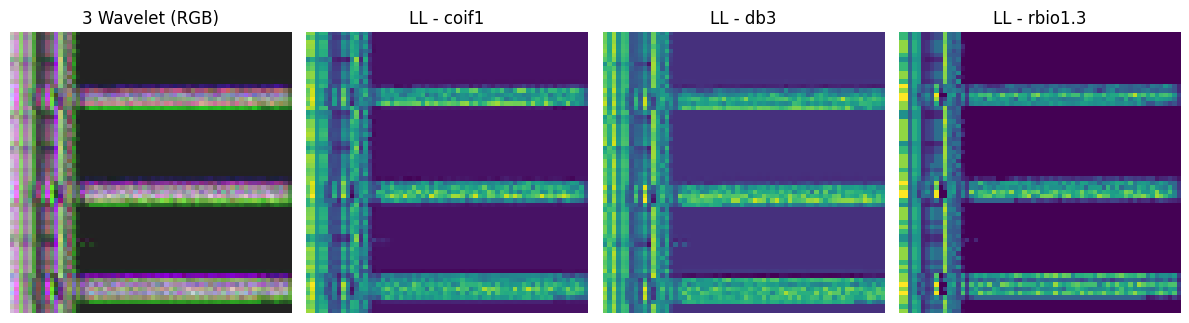

In [107]:
# ambil 1 sample untuk demo
demo_idx = 0
demo_img = X_dwt[demo_idx]

# scaling agar visual bagus
demo_vis = demo_img.copy()
demo_vis = (demo_vis - demo_vis.min()) / (demo_vis.max() - demo_vis.min() + 1e-8)

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(demo_vis)
plt.title("3 Wavelet (RGB)")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(demo_vis[:,:,0], cmap="viridis")
plt.title("LL - coif1")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(demo_vis[:,:,1], cmap="viridis")
plt.title("LL - db3")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(demo_vis[:,:,2], cmap="viridis")
plt.title("LL - rbio1.3")
plt.axis("off")

plt.tight_layout()
plt.show()

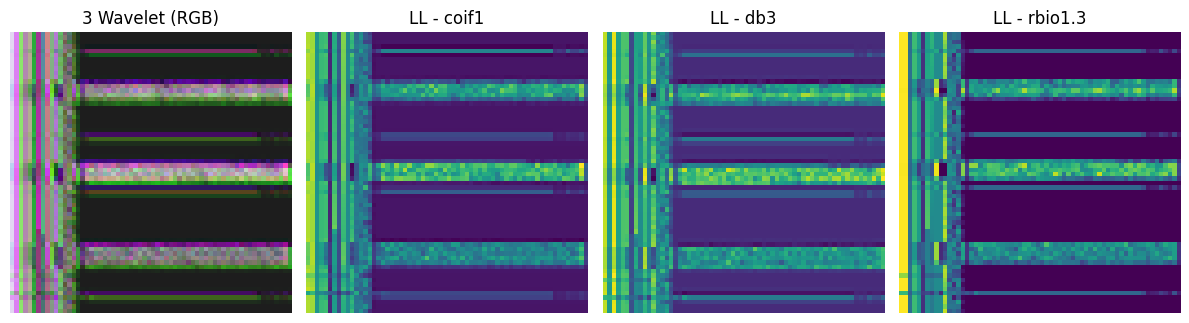

In [108]:
# ambil 1 sample untuk demo
demo_idx = 0
demo_img = X_eval_dwt[demo_idx]

# scaling agar visual bagus
demo_vis = demo_img.copy()
demo_vis = (demo_vis - demo_vis.min()) / (demo_vis.max() - demo_vis.min() + 1e-8)

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(demo_vis)
plt.title("3 Wavelet (RGB)")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(demo_vis[:,:,0], cmap="viridis")
plt.title("LL - coif1")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(demo_vis[:,:,1], cmap="viridis")
plt.title("LL - db3")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(demo_vis[:,:,2], cmap="viridis")
plt.title("LL - rbio1.3")
plt.axis("off")

plt.tight_layout()
plt.show()

In [109]:
print("Channel variance:")
print("coif1:", np.var(X_dwt[:,:, :,0]))
print("db3  :", np.var(X_dwt[:,:, :,1]))
print("rbio :", np.var(X_dwt[:,:, :,2]))


print("Channel variance:")
print("coif1:", np.var(X_eval_dwt[:,:, :,0]))
print("db3  :", np.var(X_eval_dwt[:,:, :,1]))
print("rbio :", np.var(X_eval_dwt[:,:, :,2]))

Channel variance:
coif1: 0.72897196
db3  : 0.7300782
rbio : 0.7504749
Channel variance:
coif1: 0.72969407
db3  : 0.7308259
rbio : 0.7515934


In [110]:
print(X_dwt.shape)
print(X_dwt.min(), X_dwt.max())

(3289, 64, 64, 3)
-0.72264206 4.4806385


In [111]:
print(X_eval_dwt.shape)
print(X_eval_dwt.min(), X_eval_dwt.max())

(1413, 64, 64, 3)
-0.71327895 4.0488954


In [112]:
OUT_NPZ = os.path.join(SAVE_DIR, "tow_ids_train_dwt.npz")
np.savez(OUT_NPZ, X=X_dwt, y=y)

print("Saved NPZ:", OUT_NPZ)

Saved NPZ: /home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize256lv3multiclass/norm/dwt/tow_ids_train_dwt.npz


In [113]:
OUT_NPZ = os.path.join(SAVE_DIR, "tow_ids_eval_dwt.npz")
np.savez(OUT_NPZ, X=X_eval_dwt, y=y_eval)

print("Saved NPZ:", OUT_NPZ)

Saved NPZ: /home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize256lv3multiclass/norm/dwt/tow_ids_eval_dwt.npz


In [114]:
del X, y, X_dwt, X_eval_dwt, y_eval
gc.collect()

print("Memory cleaned.")

Memory cleaned.


In [115]:
import os
import numpy as np
test_path = os.path.join(Loader, "tow_ids_test_windows_norm.npz")
# load
test_data = np.load(test_path)

X = test_data["X"]
y = test_data["y"]



In [116]:
print("X shape :", X.shape)
print("X dtype :", X.dtype)

print("y shape :", y.shape)
print("y dtype :", y.dtype)

X shape : (3092, 256, 256)
X dtype : float32
y shape : (3092,)
y dtype : int64


In [117]:


N = X.shape[0]

X_dwt = np.empty(
    (N, target_size, target_size, 3),
    dtype=np.float32
)

for i in range(N):
    X_dwt[i] = dwt_3wavelet_single(X[i], level=level)

print("DWT Done:")
print("Shape:", X_dwt.shape)

DWT Done:
Shape: (3092, 64, 64, 3)


In [118]:
print("\n=== Statistik DWT ===")
print("Min :", X_dwt.min())
print("Max :", X_dwt.max())
print("Mean:", X_dwt.mean())
print("Shape:", X_dwt.shape)


=== Statistik DWT ===
Min : -0.69433486
Max : 4.316303
Mean: 0.73378134
Shape: (3092, 64, 64, 3)


In [119]:
OUT_NPZ = os.path.join(SAVE_DIR, "tow_ids_test_dwt.npz")
np.savez(OUT_NPZ, X=X_dwt, y=y)

print("Saved NPZ:", OUT_NPZ)

Saved NPZ: /home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize256lv3multiclass/norm/dwt/tow_ids_test_dwt.npz


In [120]:
import numpy as np
import matplotlib.pyplot as plt
import os

np.random.seed(42)

# Nama label agar nama file lebih informatif
label_names = {
    0: "Normal",
    1: "C_D",
    2: "P_I",
    3: "F_I",
    4: "M_F",
    5: "C_R"
}

for label in sorted(label_names.keys()):

    # Semua index untuk label tersebut
    idx_label = np.where(y == label)[0]

    # Ambil 2 sample acak
    sample_idx = np.random.choice(idx_label, size=2, replace=False)

    for i, idx in enumerate(sample_idx, start=1):

        img = X_dwt[idx]

        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.title(f"{label_names[label]} (Label {label})")
        plt.axis("off")

        img_path = os.path.join(
            SAVE_DIR2,
            f"{label_names[label]}_sample{i}_idxtest{idx}.png"
        )

        plt.savefig(img_path, bbox_inches="tight", pad_inches=0)
        plt.close()

print("Saved 2 sample images for each class.")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5211387..3.2844756].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4242593..3.028937].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4126478..3.0274508].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2880057..3.0274508].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.40072834..3.0274508].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4922377..3.0156858].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.512896

Saved 2 sample images for each class.


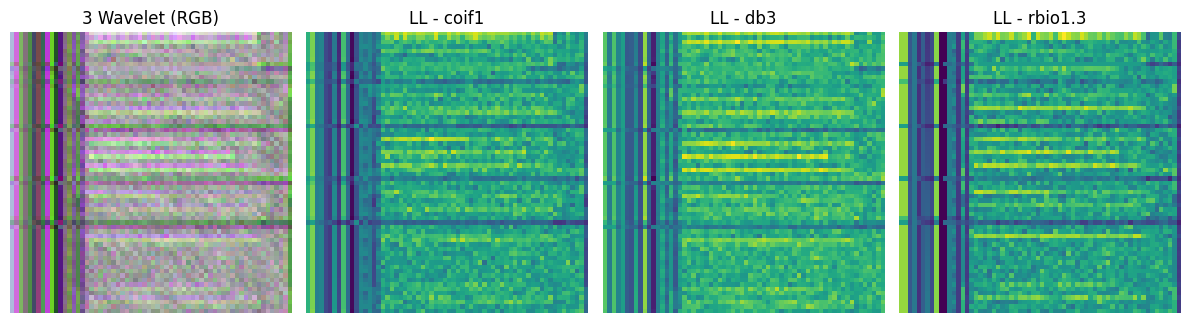

In [121]:
# ambil 1 sample untuk demo
demo_idx = 0
demo_img = X_dwt[demo_idx]

# scaling agar visual bagus
demo_vis = demo_img.copy()
demo_vis = (demo_vis - demo_vis.min()) / (demo_vis.max() - demo_vis.min() + 1e-8)

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(demo_vis)
plt.title("3 Wavelet (RGB)")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(demo_vis[:,:,0], cmap="viridis")
plt.title("LL - coif1")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(demo_vis[:,:,1], cmap="viridis")
plt.title("LL - db3")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(demo_vis[:,:,2], cmap="viridis")
plt.title("LL - rbio1.3")
plt.axis("off")

plt.tight_layout()
plt.show()

In [122]:
print("Channel variance:")
print("coif1:", np.var(X_dwt[:,:, :,0]))
print("db3  :", np.var(X_dwt[:,:, :,1]))
print("rbio :", np.var(X_dwt[:,:, :,2]))


Channel variance:
coif1: 0.7444115
db3  : 0.7447874
rbio : 0.7663404


In [123]:
del X, y, X_dwt
gc.collect()

print("Memory cleaned.")

Memory cleaned.
